# Finite Differences for CFD — A Brief Guided Lab

**Goal.** Build intuition for how finite-difference (FD) schemes turn continuous fluid equations into discrete algorithms you can code. We stay in one space dimension so every formula stays transparent.

## Learning objectives

1. Derive forward, backward, and central difference formulas from Taylor series.
2. Measure truncation error and observe the formal order of accuracy.
3. Discretize the 1-D linear **advection** equation (hyperbolic model problem).
4. Discretize the 1-D **diffusion** equation (parabolic model problem).
5. See why the CFL number matters for explicit advection schemes.

## How to use this notebook

Run cells top-to-bottom with `Shift+Enter`. Change a parameter, re-run the cell, and watch the plot.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy", np.__version__, "— ready.")


NumPy 2.4.6 — ready.


---

## 1. From Taylor series to finite differences 

Expand \(f(x+\Delta x)\) and \(f(x-\Delta x)\):

$$
\begin{aligned}
f(x+\Delta x) &= f + f'\Delta x + \frac{f''}{2}(\Delta x)^2 + \frac{f'''}{6}(\Delta x)^3 + \mathcal{O}((\Delta x)^4),\\
f(x-\Delta x) &= f - f'\Delta x + \frac{f''}{2}(\Delta x)^2 - \frac{f'''}{6}(\Delta x)^3 + \mathcal{O}((\Delta x)^4).
\end{aligned}
$$

Rearrangement immediately gives the classic formulas:

| Scheme | Formula | Truncation error |
|--------|---------|------------------|
| Forward 1st | \(f'_i \approx \dfrac{f_{i+1}-f_i}{\Delta x}\) | \(\mathcal{O}(\Delta x)\) |
| Backward 1st | \(f'_i \approx \dfrac{f_i-f_{i-1}}{\Delta x}\) | \(\mathcal{O}(\Delta x)\) |
| Central 1st | \(f'_i \approx \dfrac{f_{i+1}-f_{i-1}}{2\Delta x}\) | \(\mathcal{O}((\Delta x)^2)\) |
| Central 2nd | \(f''_i \approx \dfrac{f_{i+1}-2f_i+f_{i-1}}{(\Delta x)^2}\) | \(\mathcal{O}((\Delta x)^2)\) |

In CFD these replace \(\partial_x\), \(\partial_{xx}\), etc. inside the Navier–Stokes or model equations.


### Numerical check of order of accuracy

Take \(f(x)=\sin(2\pi x)\) on \([0,1]\). The exact derivative is \(f'=2\pi\cos(2\pi x)\).
Compute the max absolute error of each scheme for several \(\Delta x\) and plot error vs \(\Delta x\) on a log-log scale.


      dx   forward err   central err
  0.1000    1.9416e+00    4.0533e-01
  0.0500    9.7887e-01    1.0285e-01
  0.0250    4.9247e-01    2.5807e-02
  0.0125    2.4661e-01    6.4576e-03


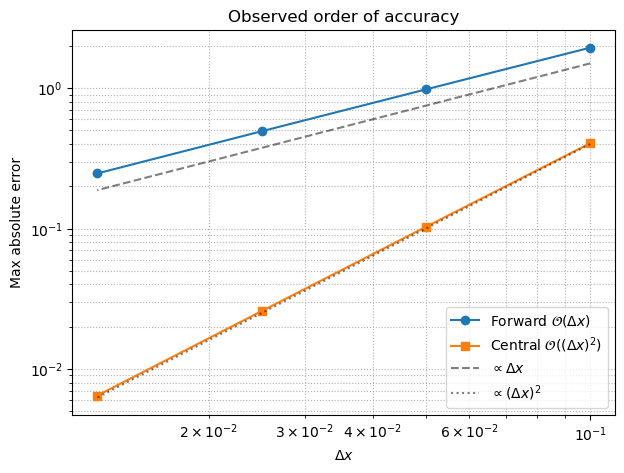

In [2]:
def f_exact(x):
    return np.sin(2 * np.pi * x)

def fp_exact(x):
    return 2 * np.pi * np.cos(2 * np.pi * x)

dx_list = np.array([0.1, 0.05, 0.025, 0.0125])
err_fwd, err_ctr = [], []

for dx in dx_list:
    x = np.arange(0, 1 + dx, dx)
    f = f_exact(x)
    # interior points only
    fp_fwd = (f[1:] - f[:-1]) / dx          # forward at x[:-1]
    fp_ctr = (f[2:] - f[:-2]) / (2 * dx)    # central at x[1:-1]
    err_fwd.append(np.max(np.abs(fp_fwd - fp_exact(x[:-1]))))
    err_ctr.append(np.max(np.abs(fp_ctr - fp_exact(x[1:-1]))))

print(f"{'dx':>8}  {'forward err':>12}  {'central err':>12}")
for dx, ef, ec in zip(dx_list, err_fwd, err_ctr):
    print(f"{dx:8.4f}  {ef:12.4e}  {ec:12.4e}")

plt.figure(figsize=(7, 5))
plt.loglog(dx_list, err_fwd, "o-", label=r"Forward $\mathcal{O}(\Delta x)$")
plt.loglog(dx_list, err_ctr, "s-", label=r"Central $\mathcal{O}((\Delta x)^2)$")
plt.loglog(dx_list, 15 * dx_list, "k--", alpha=0.5, label=r"$\propto \Delta x$")
plt.loglog(dx_list, 40 * dx_list**2, "k:", alpha=0.5, label=r"$\propto (\Delta x)^2$")
plt.xlabel(r"$\Delta x$")
plt.ylabel("Max absolute error")
plt.title("Observed order of accuracy")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()


**Checkpoint.** Halving \(\Delta x\) should roughly *halve* the forward error and *quarter* the central error. Does your table agree?

---

## 2. Model problem 1 — linear advection 

The 1-D linear advection (or transport) equation

$$
\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = 0
$$

is the simplest hyperbolic model that appears in every CFD course.
Exact solution: the initial profile travels at constant speed \(c\) without changing shape,

$$
u(x,t)=u_0(x-ct).
$$

### Upwind finite-difference scheme

For \(c>0\) information travels left → right, so a **backward** (upwind) difference is stable:

$$
\frac{u_i^{n+1}-u_i^n}{\Delta t} + c\frac{u_i^n-u_{i-1}^n}{\Delta x} = 0
$$

$$
\Rightarrow\quad u_i^{n+1} = u_i^n - \nu\,(u_i^n - u_{i-1}^n), \qquad \nu = \frac{c\Delta t}{\Delta x}\quad\text{(CFL number)}.
$$

Periodic boundaries close the domain.


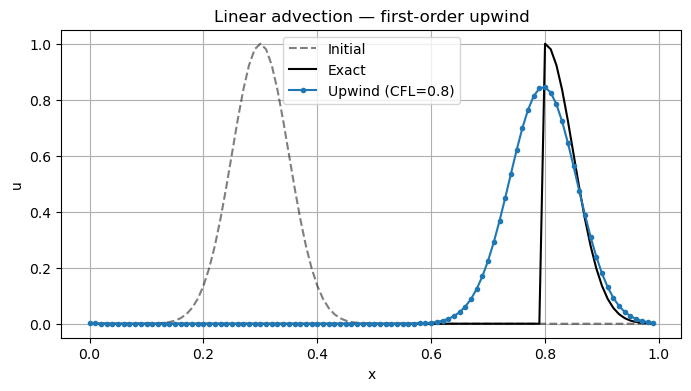

dx = 0.0100, dt = 8.0000e-03, CFL = 0.8
Max |error| = 8.4043e-01


In [3]:
def advection_upwind(u0, c, dx, dt, t_end):
    """1-D linear advection, first-order upwind, periodic BC."""
    u = u0.copy()
    n_steps = int(round(t_end / dt))
    nu = c * dt / dx          # CFL number
    for _ in range(n_steps):
        u_left = np.roll(u, 1)   # u_{i-1} with periodic wrap
        u = u - nu * (u - u_left)
    return u

# Grid and initial condition: a smooth bump
Nx = 100
L = 1.0
dx = L / Nx
x = np.linspace(0, L, Nx, endpoint=False)
u0 = np.exp(-200 * (x - 0.3)**2)   # Gaussian centred at 0.3

c = 1.0
t_end = 0.5
# Choose dt from a target CFL
CFL = 0.8
dt = CFL * dx / c

u_num = advection_upwind(u0, c, dx, dt, t_end)
u_exact = np.exp(-200 * ((x - c * t_end - 0.3) % L)**2)  # periodic shift

plt.figure(figsize=(8, 4))
plt.plot(x, u0, "k--", alpha=0.5, label="Initial")
plt.plot(x, u_exact, "k-", label="Exact")
plt.plot(x, u_num, "o-", markersize=3, label=f"Upwind (CFL={CFL})")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Linear advection — first-order upwind")
plt.legend()
plt.grid(True)
plt.show()

print(f"dx = {dx:.4f}, dt = {dt:.4e}, CFL = {CFL}")
print(f"Max |error| = {np.max(np.abs(u_num - u_exact)):.4e}")


**Tasks**

1. Set `CFL = 1.2` (above 1) and re-run. What happens?
2. Set `CFL = 0.4` and compare the amount of numerical diffusion (smoothing of the peak) with `CFL = 0.8`.
3. Why does the first-order upwind scheme *always* smear a sharp feature, even when stable?

---

## 3. Model problem 2 — diffusion 

The 1-D heat / diffusion equation

$$
\frac{\partial u}{\partial t} = \alpha\frac{\partial^2 u}{\partial x^2}
$$

is the simplest parabolic model (viscous terms in Navier–Stokes look like this).

### Explicit central scheme

Replace \(\partial_{xx}\) by the central second difference and \(\partial_t\) by a forward difference:

$$
\frac{u_i^{n+1}-u_i^n}{\Delta t} = \alpha\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{(\Delta x)^2}
$$

$$
\Rightarrow\quad u_i^{n+1} = u_i^n + r\,(u_{i+1}^n - 2u_i^n + u_{i-1}^n), \qquad r = \frac{\alpha\Delta t}{(\Delta x)^2}.
$$

Stability for the explicit scheme requires \(r \le 1/2\).


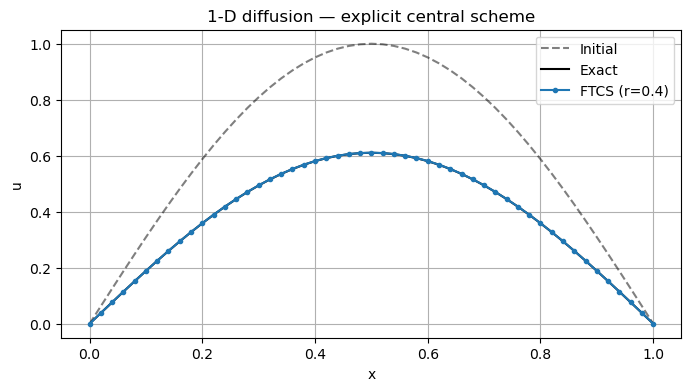

dx = 0.0200, dt = 1.6000e-03, r = 0.4
Max |error| = 3.4348e-04


In [4]:
def diffusion_explicit(u0, alpha, dx, dt, t_end, bc="dirichlet"):
    """1-D diffusion, FTCS (forward-time central-space), Dirichlet or periodic."""
    u = u0.copy()
    n_steps = int(round(t_end / dt))
    r = alpha * dt / dx**2
    for _ in range(n_steps):
        if bc == "periodic":
            u = u + r * (np.roll(u, -1) - 2 * u + np.roll(u, 1))
        else:  # Dirichlet: hold endpoints fixed
            u[1:-1] = u[1:-1] + r * (u[2:] - 2 * u[1:-1] + u[:-2])
    return u

# Initial: sine mode that is an exact eigenfunction on [0,1] with u=0 at ends
Nx = 51
L = 1.0
dx = L / (Nx - 1)
x = np.linspace(0, L, Nx)
u0 = np.sin(np.pi * x)          # exact solution: e^{-alpha pi^2 t} sin(pi x)

alpha = 0.1
t_end = 0.5
r = 0.4                         # stay safely below 0.5
dt = r * dx**2 / alpha

u_num = diffusion_explicit(u0, alpha, dx, dt, t_end, bc="dirichlet")
u_exact = np.exp(-alpha * np.pi**2 * t_end) * np.sin(np.pi * x)

plt.figure(figsize=(8, 4))
plt.plot(x, u0, "k--", alpha=0.5, label="Initial")
plt.plot(x, u_exact, "k-", label="Exact")
plt.plot(x, u_num, "o-", markersize=3, label=f"FTCS (r={r})")
plt.xlabel("x")
plt.ylabel("u")
plt.title("1-D diffusion — explicit central scheme")
plt.legend()
plt.grid(True)
plt.show()

print(f"dx = {dx:.4f}, dt = {dt:.4e}, r = {r}")
print(f"Max |error| = {np.max(np.abs(u_num - u_exact)):.4e}")


**Tasks**

1. Set `r = 0.6` and re-run. Instability should appear as growing oscillations.
2. Refine the mesh (`Nx = 101`) while keeping `r = 0.4`. How does the error change?

---

## 4. A glimpse of CFD practice 

| Concept | Advection | Diffusion |
|---------|-----------|-----------|
| PDE type | Hyperbolic | Parabolic |
| Prototype FD | Upwind (or higher-order / flux-limited) | Central 2nd difference |
| Key dimensionless number | CFL \(\nu=c\Delta t/\Delta x\le 1\) (explicit) | Fourier number \(r=\alpha\Delta t/(\Delta x)^2\le 1/2\) (explicit) |
| Typical pathology | Numerical diffusion / dispersion | Severe \(\Delta t\) restriction on fine meshes |

Real CFD codes combine both: convective fluxes (treated with upwind-biased or Riemann-solver schemes) and viscous fluxes (usually central). Multi-dimensional, unstructured, and high-order extensions all rest on the same Taylor-series foundation you used above.

### Optional extension — central advection (illustrates instability)

A pure central difference for the spatial derivative with forward Euler in time is *unconditionally unstable* for pure advection. Uncomment the cell below only if you want to see the classic blow-up.


In [5]:
# Optional: unstable central scheme for advection (forward Euler + central space)
def advection_central_unstable(u0, c, dx, dt, t_end):
    u = u0.copy()
    n_steps = int(round(t_end / dt))
    nu = c * dt / dx
    for _ in range(n_steps):
        u = u - nu * (np.roll(u, -1) - np.roll(u, 1)) / 2
    return u

# Uncomment to demonstrate instability (short time, small CFL still blows up)
# u_bad = advection_central_unstable(u0, c, dx, dt, t_end=0.2)
# plt.plot(x, u_bad); plt.title("Central advection — unstable"); plt.show()
print("Central+forward-Euler advection left commented — uncomment to see blow-up.")


Central+forward-Euler advection left commented — uncomment to see blow-up.


---

## 5. Short exercises



| # | Exercise |
|---|----------|
| 1 | Repeat the order-of-accuracy study for the **second** derivative. Confirm \(\mathcal{O}((\Delta x)^2)\). |
| 2 | Advection: fix \(\Delta x\), vary CFL from 0.2 to 0.95. Plot max error vs CFL. |
| 3 | Diffusion: start from a step function (or narrow Gaussian). Watch it spread; compare to the analytic fundamental solution if you like. |
| 4 | Replace first-order upwind by the **Lax–Friedrichs** scheme and compare numerical diffusion. |

### Workspace


In [6]:
# --- Your investigation ---
# Example skeleton for exercise 1 (second-derivative order):

def fpp_exact(x):
    return -(2 * np.pi)**2 * np.sin(2 * np.pi * x)

dx_list = np.array([0.1, 0.05, 0.025, 0.0125])
errs = []
for dx in dx_list:
    x = np.arange(0, 1 + dx, dx)
    f = f_exact(x)
    fpp = (f[2:] - 2 * f[1:-1] + f[:-2]) / dx**2
    errs.append(np.max(np.abs(fpp - fpp_exact(x[1:-1]))))

for dx, e in zip(dx_list, errs):
    print(f"dx = {dx:.4f}, max error = {e:.4e}")


dx = 0.1000, max error = 1.2191e+00
dx = 0.0500, max error = 3.2363e-01
dx = 0.0250, max error = 8.1108e-02
dx = 0.0125, max error = 2.0289e-02


In [7]:
# Figure for your report
# plt.figure(...)
# plt.savefig("fd_cfd_investigation.png", dpi=150)
# plt.show()
pass



---

## Summary

| Idea | Take-away |
|------|-----------|
| Taylor series | Source of every classical FD formula and its truncation error |
| Order of accuracy | Measured by log-log slope of error vs \(\Delta x\) |
| Advection | Upwind respects the domain of dependence; CFL \(\le 1\) for explicit schemes |
| Diffusion | Central 2nd difference + explicit time step needs \(r\le 1/2\) |
| CFD link | Convective fluxes ≈ upwind-biased FD; viscous fluxes ≈ central FD |

You now have the minimal finite-difference toolkit that underpins introductory CFD: discrete derivatives, two canonical model PDEs, and the stability limits that appear on every explicit mesh.


---

## 6. A first look at MHD (magnetohydrodynamics)

Ideal MHD couples the fluid equations to the induction equation for the magnetic field. In one dimension a particularly clean solution is the **Alfvén wave**: a transverse perturbation in velocity and magnetic field that travels at the Alfvén speed

$$
v_A = \frac{B_0}{\sqrt{\mu_0\rho_0}}
$$

(without changing density or the longitudinal field).

### Minimal 1-D system (transverse Alfvén wave)

Background: uniform density \(\rho_0\), longitudinal field \(B_x = B_0\), rest state \(v=0\).

Perturbations \(v_y(x,t)\) and \(B_y(x,t)\) obey

$$
\begin{aligned}
\partial_t v_y &= \frac{B_0}{\mu_0\rho_0}\,\partial_x B_y,\\
\partial_t B_y &= B_0\,\partial_x v_y.
\end{aligned}
$$

(We take \(\mu_0=1\) in code units, so \(v_A = B_0/\sqrt{\rho_0}\).)

A first-order **upwind / characteristic** update, or a simple staggered leapfrog-style FD scheme, lets the wave propagate. Below we use a straightforward FTCS-like update stabilized by a small amount of numerical dissipation, and compare the numerical wave speed to \(v_A\).


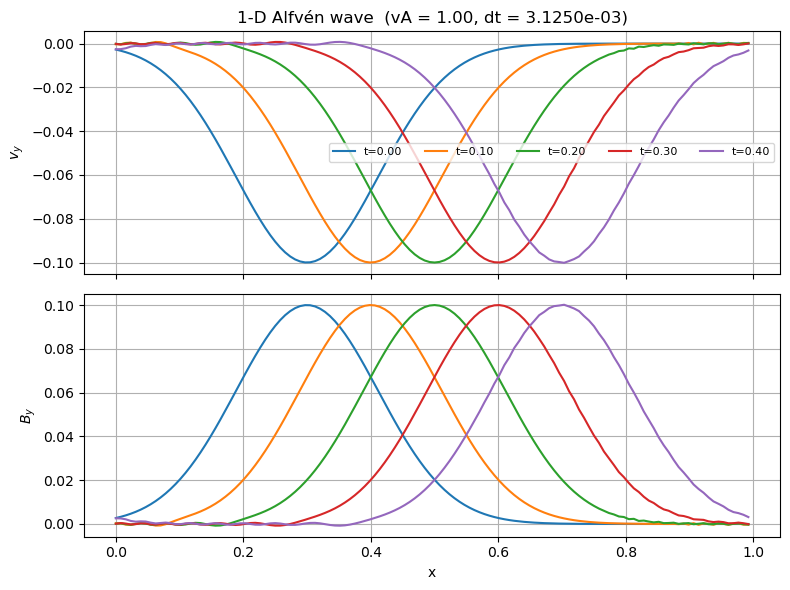

Alfvén speed vA = 1.0000
Expected travel distance in t=0.4: 0.4000


In [8]:
def alfven_wave_1d(Ny, L, rho0, B0, amp, t_end, CFL=0.4):
    """Propagate a transverse Alfvén wave with a simple FD scheme.

    State: vy, By on a periodic 1-D grid.
    Returns x, t_snapshots, vy_snapshots, By_snapshots, vA.
    """
    dx = L / Ny
    x = np.linspace(0, L, Ny, endpoint=False)
    vA = B0 / np.sqrt(rho0)

    # Initial circularly polarized-like pulse (here a Gaussian in By, vy)
    # Standing-start: vy = -vA * (By/B0) for a right-going wave packet
    By = amp * np.exp(-40 * ((x - 0.3 * L) / L)**2)
    vy = -vA * (By / B0) if B0 != 0 else np.zeros_like(By)

    dt = CFL * dx / max(vA, 1e-12)
    n_steps = int(round(t_end / dt))
    dt = t_end / max(n_steps, 1)   # land exactly on t_end

    # Store a few snapshots
    snap_times = np.linspace(0, t_end, 5)
    snaps_vy, snaps_By = [], []
    next_snap = 0

    def ddx_central(f):
        return (np.roll(f, -1) - np.roll(f, 1)) / (2 * dx)

    t = 0.0
    for step in range(n_steps + 1):
        if next_snap < len(snap_times) and t >= snap_times[next_snap] - 0.5 * dt:
            snaps_vy.append(vy.copy())
            snaps_By.append(By.copy())
            next_snap += 1
        if step == n_steps:
            break
        # Simple RK2 (Heun) on the linear system
        k1_vy = (B0 / rho0) * ddx_central(By)
        k1_By = B0 * ddx_central(vy)
        vy_mid = vy + 0.5 * dt * k1_vy
        By_mid = By + 0.5 * dt * k1_By
        k2_vy = (B0 / rho0) * ddx_central(By_mid)
        k2_By = B0 * ddx_central(vy_mid)
        vy = vy + dt * k2_vy
        By = By + dt * k2_By
        t += dt

    return x, snap_times[:len(snaps_vy)], snaps_vy, snaps_By, vA, dt


# --- Run a right-going Alfvén pulse ---
Ny = 128
L = 1.0
rho0 = 1.0
B0 = 1.0          # => vA = 1
amp = 0.1
t_end = 0.4

x, times, snaps_vy, snaps_By, vA, dt = alfven_wave_1d(
    Ny, L, rho0, B0, amp, t_end, CFL=0.4
)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for i, (t, vy, By) in enumerate(zip(times, snaps_vy, snaps_By)):
    axes[0].plot(x, vy, label=f"t={t:.2f}")
    axes[1].plot(x, By, label=f"t={t:.2f}")
axes[0].set_ylabel(r"$v_y$")
axes[1].set_ylabel(r"$B_y$")
axes[1].set_xlabel("x")
axes[0].set_title(f"1-D Alfvén wave  (vA = {vA:.2f}, dt = {dt:.4e})")
axes[0].legend(fontsize=8, ncol=5)
axes[0].grid(True)
axes[1].grid(True)
plt.tight_layout()
plt.show()

print(f"Alfvén speed vA = {vA:.4f}")
print(f"Expected travel distance in t={t_end}: {vA * t_end:.4f}")


### Ideas of things to look at

Use the simulation above (and small parameter changes) to explore:

| # | Question | What to change / measure |
|---|----------|---------------------------|
| 1 | **Wave speed** | Does the pulse peak move at \(v_A = B_0/\sqrt{\rho_0}\)? Track the location of \(\max|B_y|\) vs time. |
| 2 | **\(B_0\) dependence** | Double \(B_0\). Does the pulse travel twice as fast? |
| 3 | **Density dependence** | Double \(\rho_0\). Does \(v_A\) drop by \(\sqrt{2}\)? |
| 4 | **Polarization / relation** | For a pure right-going Alfvén wave, \(v_y \approx -v_A B_y/B_0\). Plot \(v_y\) vs \(B_y/B_0\) at a fixed time. |
| 5 | **Energy partition** | Magnetic energy \(\propto B_y^2\) and kinetic energy \(\propto\rho_0 v_y^2\) should stay nearly equal and constant for a linear Alfvén wave. Plot both vs time. |
| 6 | **Numerical dissipation** | Refine \(N_y\) (64 → 128 → 256). Does the pulse stay sharper longer? |
| 7 | **CFL / stability** | Raise `CFL` toward 1 and beyond. When does the scheme go unstable? |
| 8 | **Left-going wave** | Flip the initial relation to \(v_y = +v_A B_y/B_0\). Does the pulse travel the other way? |
| 9 | **Superposition** | Start with two pulses of opposite polarity. Do they pass through each other linearly? |
| 10 | **Link to pure advection** | Set a uniform \(v_x\) and a passive \(B_y\) (no back-reaction). Compare “field freezing” to the coupled Alfvén case. |

### Quick energy diagnostic


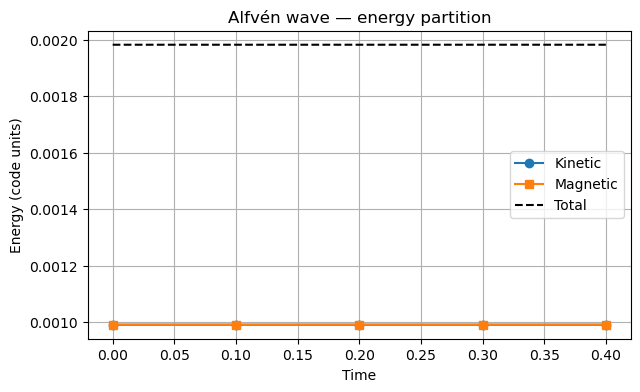

Initial E_kin, E_mag: 0.0009907722728678407 0.0009907722728678407
Final   E_kin, E_mag: 0.0009907929326910844 0.0009907929326910844


In [9]:
# Energy partition for the Alfvén run above
# Recompute with stored snapshots (kinetic + magnetic, mu0=1)
E_kin = [0.5 * rho0 * np.sum(vy**2) * (L / Ny) for vy in snaps_vy]
E_mag = [0.5 * np.sum(By**2) * (L / Ny) for By in snaps_By]

plt.figure(figsize=(7, 4))
plt.plot(times[:len(E_kin)], E_kin, "o-", label="Kinetic")
plt.plot(times[:len(E_mag)], E_mag, "s-", label="Magnetic")
plt.plot(times[:len(E_kin)], np.array(E_kin) + np.array(E_mag), "k--", label="Total")
plt.xlabel("Time")
plt.ylabel("Energy (code units)")
plt.title("Alfvén wave — energy partition")
plt.legend()
plt.grid(True)
plt.show()

print("Initial E_kin, E_mag:", E_kin[0], E_mag[0])
print("Final   E_kin, E_mag:", E_kin[-1], E_mag[-1])


### Workspace for MHD exploration

Change parameters, re-run, and record one observation.


In [10]:
# --- Your MHD investigation ---
# Example: measure numerical wave speed from peak tracking

def pulse_peak_x(x, By):
    return x[np.argmax(np.abs(By))]

peaks = [pulse_peak_x(x, By) for By in snaps_By]
# unwrap possible periodic jump
peaks = np.asarray(peaks)
for i in range(1, len(peaks)):
    if peaks[i] < peaks[i-1] - 0.5 * L:
        peaks[i:] += L

if len(peaks) >= 2 and times[-1] > times[0]:
    v_num = (peaks[-1] - peaks[0]) / (times[len(peaks)-1] - times[0])
    print(f"Tracked peak speed  ≈ {v_num:.4f}")
    print(f"Analytic Alfvén speed = {vA:.4f}")
    print(f"Relative error        = {abs(v_num - vA)/vA:.2%}")
else:
    print("Not enough snapshots to estimate speed.")


Tracked peak speed  ≈ 1.0156
Analytic Alfvén speed = 1.0000
Relative error        = 1.56%


**Take-away.** Even this minimal FD MHD model recovers the essential physics: a magnetic field supports a wave at speed \(v_A\), kinetic and magnetic energy stay in equipartition, and the same CFL-type limits you saw for pure advection reappear with \(v_A\) in place of \(c\). Full ideal MHD (density, pressure, all three velocity and field components, divergence-free constraints) builds on the same finite-difference ideas.
